In [77]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [78]:
df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')
df

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",False,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,False,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,False,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,True,1392,Freight Included in Commodity Cost,134.03


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

In [80]:
cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]

df = df[cols_to_keep]


In [81]:
df

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd)
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2-Jun-06,2-Jun-06,780.34,NaN
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,14-Nov-06,14-Nov-06,4521.5,NaN
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,27-Aug-06,27-Aug-06,1653.78,NaN
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,1-Sep-06,1-Sep-06,16007.06,NaN
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,11-Aug-06,11-Aug-06,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,31-Jul-15,15-Jul-15,See DN-4307 (ID#:83920),705.79
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,31-Jul-15,6-Aug-15,See DN-4313 (ID#:83921),161.71
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,31-Aug-15,25-Aug-15,Freight Included in Commodity Cost,5284.04
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,9-Sep-15,4-Aug-15,Freight Included in Commodity Cost,134.03


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    10324 non-null  object 
 1   vendor                     10324 non-null  object 
 2   shipment mode              9964 non-null   object 
 3   product group              10324 non-null  object 
 4   sub classification         10324 non-null  object 
 5   po sent to vendor date     10324 non-null  object 
 6   scheduled delivery date    10324 non-null  object 
 7   delivered to client date   10324 non-null  object 
 8   freight cost (usd)         10324 non-null  object 
 9   line item insurance (usd)  10037 non-null  float64
dtypes: float64(1), object(9)
memory usage: 806.7+ KB


In [83]:
list_to_date = [ 'scheduled delivery date', 'delivered to client date']

for i in list_to_date:
    df[i] = pd.to_datetime(df[i])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    10324 non-null  object        
 1   vendor                     10324 non-null  object        
 2   shipment mode              9964 non-null   object        
 3   product group              10324 non-null  object        
 4   sub classification         10324 non-null  object        
 5   po sent to vendor date     10324 non-null  object        
 6   scheduled delivery date    10324 non-null  datetime64[ns]
 7   delivered to client date   10324 non-null  datetime64[ns]
 8   freight cost (usd)         10324 non-null  object        
 9   line item insurance (usd)  10037 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 806.7+ KB


C:\Users\HP\AppData\Local\Temp\ipykernel_28500\3904375590.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_28500\3904375590.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_28500\3904375590.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[i] = pd.to_datetime(df[i])
C:\Users\HP\AppData\Local\Temp\ipykernel_28500\390437559

In [84]:
df_delai = df.copy()

In [85]:
df_delai['delay'] = (df['scheduled delivery date'] - df['delivered to client date']).dt.days
df_delai



,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36


In [ ]:
df_delai_count = df_delai.value_counts('delay').head(19).to_frame()
df_delai_count

,count
delay,
0,6324
17,127
6,119
8,112
13,107
7,106
2,93
-1,92
19,85


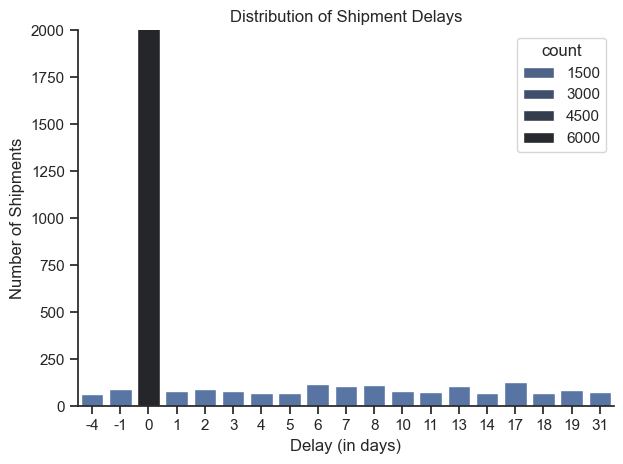

In [175]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_delai_count,
            x = 'delay',
            y = 'count',           
            hue = 'count',
            palette = 'dark:b_r',
           )
sns.despine()   

plt.ylim(0,2000)
plt.xlabel('Delay (in days)')
plt.ylabel('Number of Shipments')
plt.title('Distribution of Shipment Delays')

plt.tight_layout()
plt.show()

In [176]:
df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',
    np.where(
        df_delai['delay'] == 0, 'on time',
    'late')
)

df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


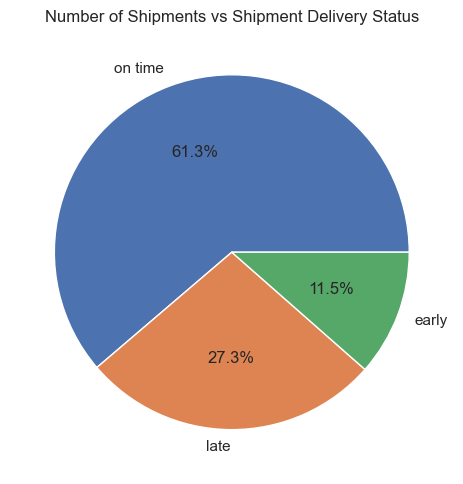

In [177]:
df_delai['shipment delivery'].value_counts().plot(kind = 'pie',
                xlabel = '', 
                ylabel = '',
                title = 'Number of Shipments vs Shipment Delivery Status',
                figsize = (8,5),
                autopct = '%1.1f%%',
                  )

plt.tight_layout()
plt.show()